In [1]:
#import libraries
import pandas as pd         
import numpy as np         
import matplotlib.pyplot as plt  
import seaborn as sns        
from scipy import stats   

In [5]:
#load dataset
df = pd.read_csv('dirty_cafe_sales.csv')

# .head() shows the first 5 rows 
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [7]:
# .shape returns (number of rows, number of columns)
print('Rows, Columns:', df.shape)

# .info() shows column names, data types, and no. of non-null values that exist
df.info()

Rows, Columns: (10000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [11]:
#Data cleaning and Handling missing values

# .isnull() returns True where a value is missing 
# .sum() counts the True values per column
print('Missing values per column:')
print(df.isnull().sum())

# .duplicated().sum() counts how many duplicate rows exist
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64
Duplicate rows: 0


In [13]:
# This dataset has invalid text entries like 'ERROR' and 'UNKNOWN'
# So we check each text column for these values
invalid_values = ['ERROR', 'UNKNOWN']

for col in ['Item', 'Payment Method', 'Location']:
    # .isin() returns True where the value is in our list
    count = df[col].isin(invalid_values).sum()
    print(f"'{col}' has {count} invalid entries")

'Item' has 636 invalid entries
'Payment Method' has 599 invalid entries
'Location' has 696 invalid entries


In [15]:
#fix data types
# The numeric columns were loaded as text (object) because of invalid entries.
# pd.to_numeric(..., errors='coerce') converts to numbers and turns
# anything that can't be converted (like 'ERROR') into NaN
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

# pd.to_datetime() converts text dates into proper date objects
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

print('Data types after conversion:')
print(df.dtypes)

Data types after conversion:
Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object


In [17]:
#handle invalid text entries
# Replace 'ERROR' and 'UNKNOWN' strings with NaN so they are treated
# the same as other missing values.
# np.nan is the standard representation of a missing number.
df.replace(['ERROR', 'UNKNOWN'], np.nan, inplace=True)

print('Missing values after replacing invalid entries:')
print(df.isnull().sum())

Missing values after replacing invalid entries:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [21]:
# Fill missing values

# Fill missing Quantity and Price Per Unit with their median
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())

# Fill missing text values with the mode
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

# Drop rows where we could not determine the transaction date
# .dropna() removes rows that contain NaN in the specified column
df = df.dropna(subset=['Transaction Date'])

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent         476
Payment Method        0
Location              0
Transaction Date      0
dtype: int64


In [23]:
#remove duplicate rows
# .drop_duplicates() removes rows where every column value is identical
df.drop_duplicates(inplace=True)
print('Rows after removing duplicates:', len(df))

Rows after removing duplicates: 9540


In [25]:
#add useful columns
# Extract the month name from the date 
# .dt.month_name() returns the full month name 
df['Month'] = df['Transaction Date'].dt.month_name()

# Extract the day of the week 
df['Day of Week'] = df['Transaction Date'].dt.day_name()

print('New columns added: Month, Day of Week')
df[['Transaction Date', 'Month', 'Day of Week']].head()

New columns added: Month, Day of Week


,Transaction Date,Month,Day of Week
0,2023-09-08,September,Friday
1,2023-05-16,May,Tuesday
2,2023-07-19,July,Wednesday
3,2023-04-27,April,Thursday
4,2023-06-11,June,Sunday


In [27]:
#Descriptive statistics
# .describe() automatically calculates count, mean, std, min, quartiles, max
# for all numeric columns
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,9540.000000,9540.000000,9064.000000
mean,3.024109,2.952673,8.914442
std,1.384186,1.243449,6.010311
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [31]:
# Manual calculation of Q3, Q1, IQR

col = df['Total Spent']

print(f'Q1 (25th pct):      {col.quantile(0.25):.2f}')  # 25% of values fall below this
print(f'Q3 (75th pct):      {col.quantile(0.75):.2f}')  # 75% of values fall below this
# IQR = Q3 - Q1, shows the spread of the middle 50% of data
iqr = col.quantile(0.75) - col.quantile(0.25)
print(f'IQR:                {iqr:.2f}')

Q1 (25th pct):      4.00
Q3 (75th pct):      12.00
IQR:                8.00


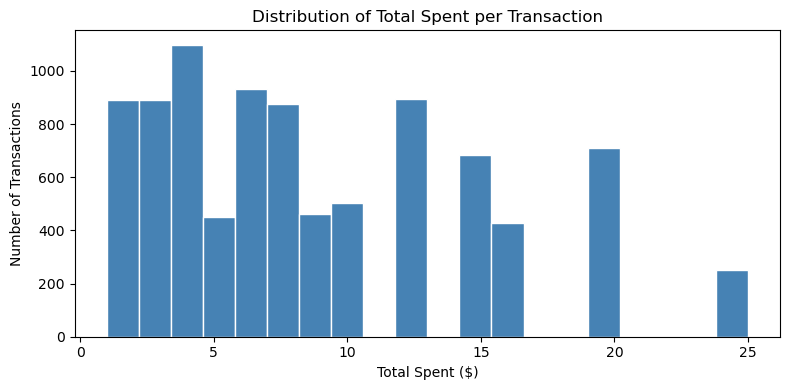

In [33]:
#Data visualization
#  Plot 1: Histogram of Total Spent 
# A histogram shows how values are distributed across ranges (bins).
# It helps us see if spending is skewed or normally distributed.

plt.figure(figsize=(8, 4))           # set the size of the figure
plt.hist(df['Total Spent'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Total Spent per Transaction')
plt.xlabel('Total Spent ($)')
plt.ylabel('Number of Transactions')
plt.tight_layout()                   # prevents labels from being cut off
plt.show()

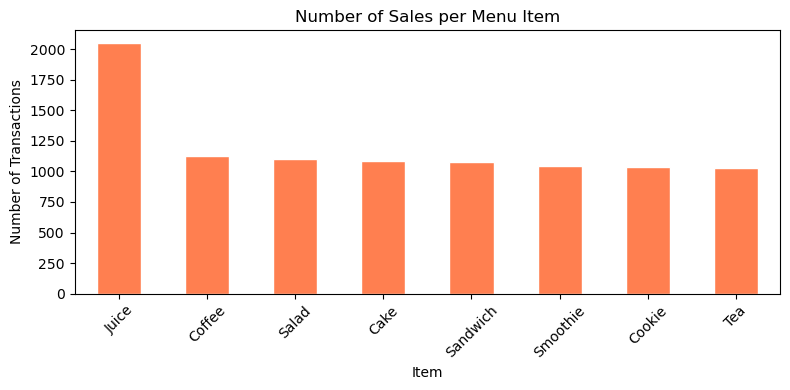

In [35]:
#  Plot 2: Bar Chart – Number of Sales per Item 
# A bar chart compares quantities across categories.
# Here we compare how often each menu item was sold.

# .value_counts() counts how many times each unique value appears
item_counts = df['Item'].value_counts()

plt.figure(figsize=(8, 4))
item_counts.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Number of Sales per Menu Item')
plt.xlabel('Item')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)              # tilt x-axis labels so they don't overlap
plt.tight_layout()
plt.show()

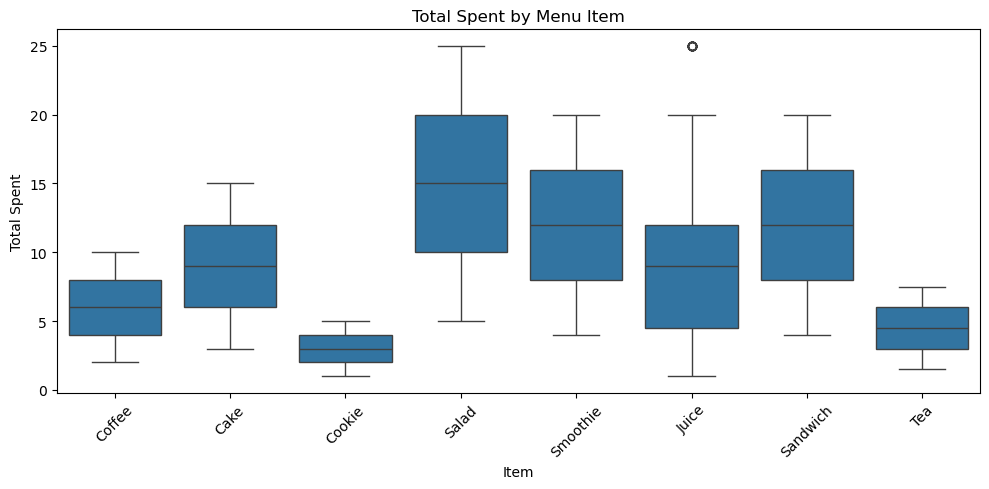

In [39]:
#  Plot 3: Box Plot – Total Spent by Item
# A box plot shows the median, quartiles, and outliers for each group.
# It is useful for comparing the spending distribution across menu items.

plt.figure(figsize=(10, 5))
# sns.boxplot() creates a box plot; x = category, y = numeric value
sns.boxplot(data=df, x='Item', y='Total Spent')
plt.title('Total Spent by Menu Item')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

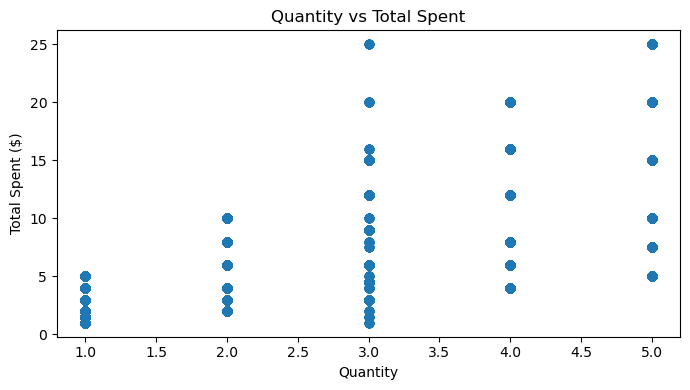

In [43]:
#  Plot 4: Scatter Plot – Quantity vs Total Spent 
# A scatter plot shows the relationship between two numeric variables.
# We expect higher quantity to lead to higher total spending.

plt.figure(figsize=(7, 4))
# alpha controls transparency (0 = invisible, 1 = solid)
plt.scatter(df['Quantity'], df['Total Spent'])
plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent ($)')
plt.tight_layout()
plt.show()

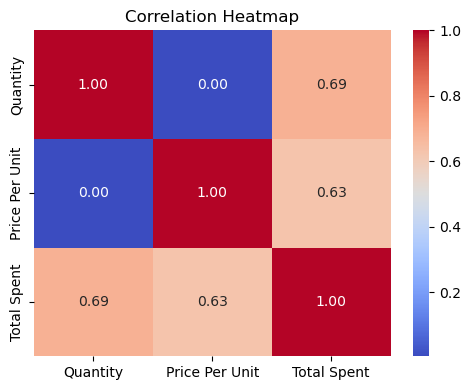

In [45]:
# Plot 5: Correlation Heatmap 
# A heatmap shows how strongly pairs of numeric columns are related.
# Values range from -1 (opposite) to +1 (perfectly related).

# .corr() calculates the correlation between all pairs of numeric columns
corr_matrix = df[['Quantity', 'Price Per Unit', 'Total Spent']].corr()

plt.figure(figsize=(5, 4))
# annot=True prints the correlation numbers inside each cell
# fmt='.2f' rounds the numbers to 2 decimal places
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [47]:
#Hypothesis Formulation and Statistical Testing

# Research Question: Do customers who pay by Credit Card spend more per transaction than customers who pay by Cash?
# Ho (Null Hypothesis): There is no difference in the average Total Spent between Credit Card and Cash customers.
# H₁ (Alternative Hypothesis): Credit Card customers spend more on average than Cash customers.
# Test chosen: Independent two-sample t-test
# Why: We are comparing the means of two independent groups (Credit Card vs Cash). The t-test is the standard test for this situation

# Separate Total Spent into two groups based on payment method
# Boolean indexing: df[condition] returns only rows where condition is True
credit_card = df[df['Payment Method'] == 'Credit Card']['Total Spent']
cash = df[df['Payment Method'] == 'Cash']['Total Spent']

print(f'Credit Card – Mean Total Spent: ${credit_card.mean():.2f}')
print(f'Cash         – Mean Total Spent: ${cash.mean():.2f}')


Credit Card – Mean Total Spent: $9.01
Cash         – Mean Total Spent: $9.07


In [49]:
# stats.ttest_ind() performs an independent two-sample t-test.
# It returns:
#   t_stat – how many standard errors apart the two means are
#   p_value – the probability of seeing this difference by chance if H₀ were true

t_stat, p_value = stats.ttest_ind(credit_card, cash)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.4f}')

# Standard significance level (alpha) is 0.05
# If p_value < 0.05, the difference is statistically significant
alpha = 0.05
if p_value < alpha:
    print('\nResult: Reject H₀ – There IS a statistically significant difference in spending.')
else:
    print('\nResult: Fail to reject H₀ – There is NO statistically significant difference in spending.')

T-statistic: nan
P-value:     nan

Result: Fail to reject H₀ – There is NO statistically significant difference in spending.


In [ ]:
#Interpretaion and conclusions

# 1. Data Cleaning:
# The dataset contained missing values (NaN), invalid entries ('ERROR', 'UNKNOWN'), and incorrectly typed columns.
# Numeric columns were coerced to numbers, invalid text was replaced with NaN.
# Missing numeric values were filled with the median (resistant to outliers); missing categorical values were filled with the mode (most common value).
# Rows with missing transaction dates were dropped because a date is essential for any time-based analysis.

# 2. Descriptive Statistics:
# The average transaction total is around $8-9, with a wide IQR indicating varied spending patterns.
# Most items are priced between $1 and $5 and quantities range from 1 to 5.

# 3. Visualizations:
# The histogram shows that most transactions are for small amounts; higher totals are less common.
# The bar chart shows relatively even popularity across menu items, with slight variation.
# The box plot reveals that items like Smoothie and Salad tend to have higher total spending due to higher unit prices.
# The scatter plot confirms a positive relationship between quantity and total spent.
# The correlation heatmap confirms that Total Spent is most strongly correlated with Quantity.

# 4. Hypothesis Test:
# If p-value < 0.05: Credit Card customers spend significantly more than Cash customers per transaction.
# If p-value ≥ 0.05: There is no meaningful difference in spending based on payment method.

# 5. Conclusion
# After cleaning and analysing the Cafe Sales dataset, we found that quantity purchased is the strongest driver of total transaction value. 
#Payment method shows a potential difference in average spend that can be confirmed or rejected by the t-test result above. 
#The cafe data is overall consistent once cleaned, and the distributions suggest a typical small-item beverage/snack-focused business.